In [2]:
# Define the number of cores per MPI rank
num_threads = 1

In [3]:
import os
# Set environment variables BEFORE importing torch or numpy
os.environ["MKL_NUM_THREADS"] = str(num_threads)
os.environ["NUMEXPR_NUM_THREADS"] = str(num_threads)
os.environ["OMP_NUM_THREADS"] = str(num_threads)
os.environ["OPENBLAS_NUM_THREADS"] = str(num_threads)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(num_threads)

from mpi4py import MPI
import numpy as np
import quimb.tensor as qtn
import pickle
from functools import partial
import torch
import json
import autoray as ar
# ==============================================================================
from vmc_torch.experiment.vmap.vmap_utils import random_initial_config, sample_next_reuse, sample_next, evaluate_energy, evaluate_energy_reuse, compute_grads
from vmc_torch.experiment.vmap.vmap_models import (
    Transformer_fPEPS_Model_Cluster_reuse,
    Transformer_fPEPS_Model_Cluster,
    fPEPS_Model_reuse
)
from vmc_torch.experiment.vmap.vmap_modules import distributed_minres_solver, run_sampling_phase_reuse
from vmc_torch.hamiltonian_torch import spinful_Fermi_Hubbard_square_lattice_torch
from vmc_torch.experiment.tn_model import init_weights_to_zero
from vmc_torch.experiment.vmap.vmap_torch_utils import robust_svd_err_catcher_wrapper
from vmc_torch.optimizer import DecayScheduler
import symmray as sr
import warnings

# ==============================================================================
warnings.filterwarnings("ignore")
torch.set_num_threads(num_threads)
# torch.set_num_interop_threads(num_threads)
# ==============================================================================
SVD_JITTER = 1e-16
driver = None
ar.register_function('torch','linalg.svd', lambda x: robust_svd_err_catcher_wrapper(x, jitter=SVD_JITTER, driver=driver))
# ==============================================================================
COMM = MPI.COMM_WORLD
RANK = COMM.Get_rank()
SIZE = COMM.Get_size()
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/vmc_torch/experiment/vmap/data'
torch.set_default_device("cpu")
torch.random.manual_seed(42 + RANK)


/tmp/ipykernel_1047402/2662687707.py:19: FutureWarning: The vmap_models module is deprecated and will be removed in future versions. Please use the updated models in .models directory instead.
  from vmc_torch.experiment.vmap.vmap_models import (


In [4]:

# ==============================================================================
# 1. Initialization & Configuration
# ==============================================================================
Lx, Ly = 8, 8
N_f = Lx * Ly
D, chi = 10, 40
t, U = 1.0, 8.0
dtype = torch.float64

# Load PEPS
peps = sr.networks.PEPS_fermionic_rand(
    "Z2",
    Lx,
    Ly,
    D,
    phys_dim=[
        (0, 0),  # linear index 0 -> charge 0, offset 0
        (1, 1),  # linear index 1 -> charge 1, offset 1
        (1, 0),  # linear index 2 -> charge 1, offset 0
        (0, 1),  # linear index 3 -> charge 0, offset 1
    ],
    subsizes="equal",
    flat=True,
    seed=42,
    dtype=str(dtype).split(".")[-1],
)

# ==============================================================================
# Model Configuration (Define this FIRST)
# ==============================================================================
# Put all hyperparameters for initialization here
# Note: ftn (peps) is usually too large or an object, not suitable for json storage, only record the parameters used to generate peps (Lx, Ly, etc.)
model_config = {
    'max_bond': chi,
    'embed_dim': 16,
    'attn_depth': 1,
    'attn_heads': 4,
    'nn_hidden_dim': D, #peps.nsites,
    'init_perturbation_scale': 1e-3,
    'nn_eta': 1,
    'dtype_str': 'float64',
    'uniform_kernel': 0,
}
dtype_map = {'float64': torch.float64, 'float32': torch.float32}
model_dtype = dtype_map[model_config['dtype_str']]
init_kwargs = model_config.copy()
init_kwargs.pop('dtype_str')
# Model
# fpeps_model = Transformer_fPEPS_Model_Conv2d(
#     tn=peps,
#     dtype=model_dtype,
#     **init_kwargs
# )
fpeps_model = Transformer_fPEPS_Model_Cluster_reuse(
    tn=peps,
    dtype=model_dtype,
    contract_boundary_opts={
        'mode': 'mps',
        # 'equalize_norms': 1.0,
        'canonize': True,
    },
    **init_kwargs
)
fpeps_model1 = Transformer_fPEPS_Model_Cluster(
    tn=peps,
    dtype=model_dtype,
    contract_boundary_opts={
        'mode': 'mps',
        'equalize_norms': 1.0,
        'canonize': True,
    },
    **init_kwargs
)
fpeps_model2 = fPEPS_Model_reuse(
    tn=peps,
    dtype=model_dtype,
    contract_boundary_opts={
        'mode': 'mps',
        # 'equalize_norms': 1.0,
        'canonize': True,
    },
    **init_kwargs
)
n_params = sum(p.numel() for p in fpeps_model.parameters())
if RANK == 0: 
    print(f'Model Params: {n_params}')

# Hamiltonian
H = spinful_Fermi_Hubbard_square_lattice_torch(
    Lx, Ly, t, U, N_f, pbc=False, n_fermions_per_spin=(N_f//2, N_f//2), no_u1_symmetry=False,
)

# VMC Hyperparams
Ns = int(6e3) 
B = 1#*num_threads
B_grad = 1#*num_threads
vmc_steps = 50
init_step = 0
burn_in_steps = 5
learning_rate = 0.1
diag_shift = 1e-4
save_state_every = 10
scheduler = DecayScheduler(init_lr=learning_rate, decay_rate=0.9, patience=50, min_lr=1e-2)

# # Load Checkpoint
# file_path = f'{params_path}/{fpeps_model._get_name()}/chi={chi}/'
# fpeps_model.debug_file = file_path
# if init_step > 0:
#     ckpt_path = file_path + f'checkpoint_step_{init_step}.pt'
#     fpeps_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
#     fpeps_model1.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
#     if RANK == 0: 
#         print(f'Loaded step {init_step}')

fpeps_model_params = fpeps_model.state_dict()
fpeps_model1.load_state_dict(fpeps_model_params)

fxs0 = torch.stack([random_initial_config(N_f, peps.nsites) for _ in range(B)]).to(torch.long)
fpeps_model2.cache_bMPS_skeleton(fxs0[0])
print(f'Batch size: {B}, Grad Batch Size: {B_grad}')

 -> [Init] LocalClusterBackflow: Clamping output weights to scale 0.001
 -> [Init] LocalClusterBackflow: Clamping output weights to scale 0.001
Model Params: 9377408
Batch size: 1, Grad Batch Size: 1


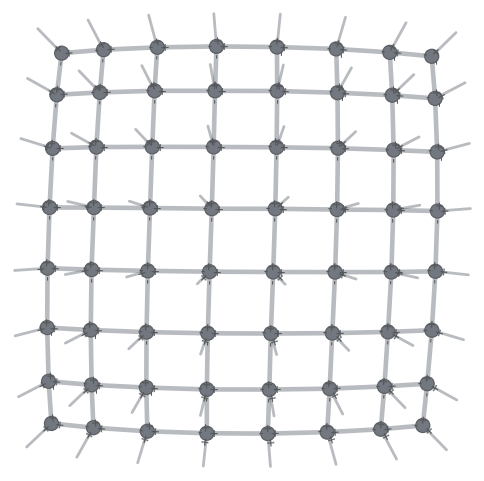

In [5]:
peps.draw()

In [4]:
# import time
# fxs = fxs0.clone()
# with torch.no_grad():
#     # t0 = time.time()
#     # # reuse_amps = fpeps_model(fxs)
#     # reuse_fxs, reuse_amps = sample_next_reuse(fxs0.clone(), fpeps_model, H.graph, show_pbar=True)
    
#     t1 = time.time()
#     # amps1 = fpeps_model1(fxs)
#     fxs1, amps1 = sample_next(fxs0.clone(), fpeps_model1, H.graph, show_pbar=True)
#     t2 = time.time()
#     E, loc_Es = evaluate_energy(fxs1, fpeps_model1, H, amps1, show_pbar=True)
#     t3 = time.time()
#     # fxs1 = fxs0.clone()
#     amps1 = fpeps_model1(fxs1)
    
# fxs1 = fxs0.clone()
# grads, _ = compute_grads(fxs1, fpeps_model1, vectorize=True, vmap_grad=True, batch_size=B_grad, show_pbar=True)
# t4 = time.time()

# t2-t1, t3-t2, t4-t3


In [17]:
batch_sizes = [1, 2, 4, 6, 8, 10]
sampling_times = []
for batchsize in batch_sizes:
    import time
    fxs0 = torch.stack([random_initial_config(N_f, peps.nsites) for _ in range(batchsize)]).to(torch.long)
    with torch.no_grad():  
        t1 = time.time()
        fxs2, amps2 = sample_next_reuse(fxs0.clone(), fpeps_model2, H.graph, show_pbar=True)
        t2 = time.time()
        E, loc_Es = evaluate_energy_reuse(fxs2, fpeps_model2, H, amps2, show_pbar=True)
        t3 = time.time()
        
    fxs2 = fxs0.clone()
    grads, _ = compute_grads(fxs2, fpeps_model2, vectorize=True, vmap_grad=True, batch_size=B_grad, show_pbar=True)
    t4 = time.time()

    sampling_times.append((t2-t1, t3-t2, t4-t3))



Computing gradients with vmap(grad): 100%|██████████| 10/10 [00:29<00:00,  2.97s/it]


In [ ]:
import matplotlib.pyplot as plt
sampling_times = np.array(sampling_times)
pure_sample_times = sampling_times[:, 0]
energy_eval_times = sampling_times[:, 1]
total_times = pure_sample_times + energy_eval_times

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(batch_sizes, pure_sample_times, marker='o')
ax[0].plot(batch_sizes, [pure_sample_times[0]*b for b in batch_sizes], linestyle='--', label='Sequntial Calc Time')
ax[0].set_xlabel('Batch Size')
ax[0].set_ylabel('Wall Time (s)')
ax[0].set_title('Sampling Sweep Time')
ax[1].plot(batch_sizes, energy_eval_times, marker='o')
ax[1].plot(batch_sizes, [energy_eval_times[0]*b for b in batch_sizes], linestyle='--', label='Sequntial Calc Time')
ax[1].set_xlabel('Batch Size')
ax[1].set_ylabel('Wall Time (s)')
ax[1].set_title('Local Energy Evaluation Time')
ax[2].plot(batch_sizes, total_times, marker='o')
ax[2].plot(batch_sizes, [total_times[0]*b for b in batch_sizes], linestyle='--', label='Sequntial Calc Time')
ax[2].set_xlabel('Batch Size')
ax[2].set_ylabel('Wall Time (s)')
ax[2].set_title('Total Time (Sampling + Energy Eval)')
for a in ax:
    a.legend()
plt.tight_layout()
plt.suptitle(rf'VMC Time Cost Scaling with Batch Size ($D={D}, \chi={chi}$)', y=1.05)
plt.savefig(f'./debug/D={D}_sampling_time_B_scaling.pdf', dpi=300)
plt.show()

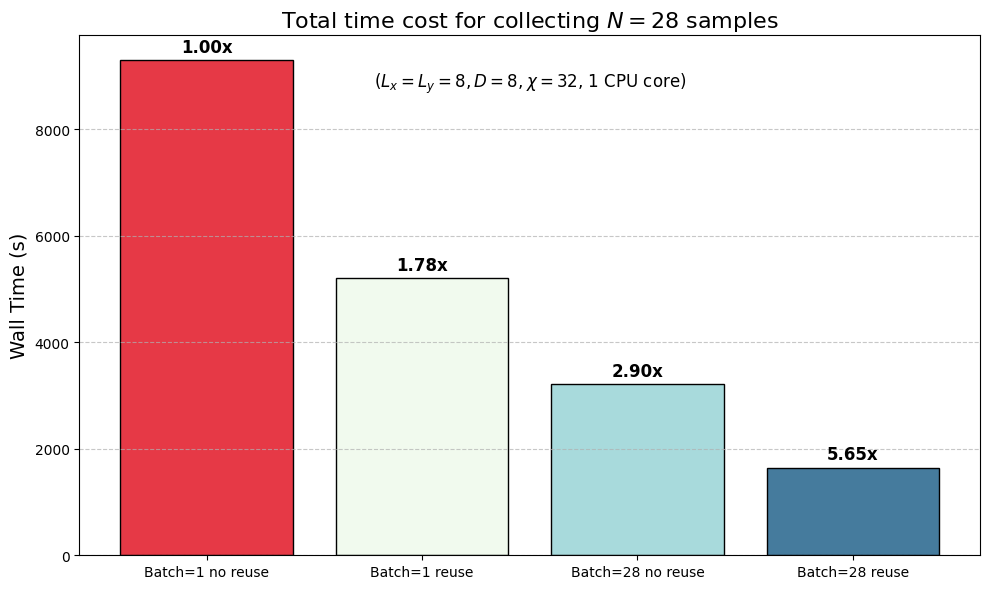

In [13]:
import matplotlib.pyplot as plt

# Data
B1_no_reuse = 332 * 28
B1_reuse = 186 * 28
B28_no_reuse = 3208
B28_reuse = 1646

times = [B1_no_reuse, B1_reuse, B28_no_reuse, B28_reuse]
labels = ['Batch=1 no reuse', 'Batch=1 reuse', 'Batch=28 no reuse', 'Batch=28 reuse']
# Calculate speedup relative to the baseline
speedups = [B1_no_reuse / t for t in times]

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(labels, times, color=['#e63946', '#f1faee', '#a8dadc', '#457b9d'], edgecolor='black')

# Labeling speedup on top
# fmt='%.2f' handles the float formatting
# padding is the distance between bar top and text
ax.bar_label(bars, labels=[f'{s:.2f}x' for s in speedups], padding=3, fontsize=12, fontweight='bold')

ax.set_ylabel('Wall Time (s)', fontsize=14)
ax.set_title(r'Total time cost for collecting $N=28$ samples', fontsize=16)
ax.text(0.5, 0.9, '($L_x=L_y=8, D=8, \chi=32$, 1 CPU core)', fontsize=12, ha='center', transform=ax.transAxes)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('./debug/NN-fPEPS_timing.pdf', dpi=300)
plt.show()

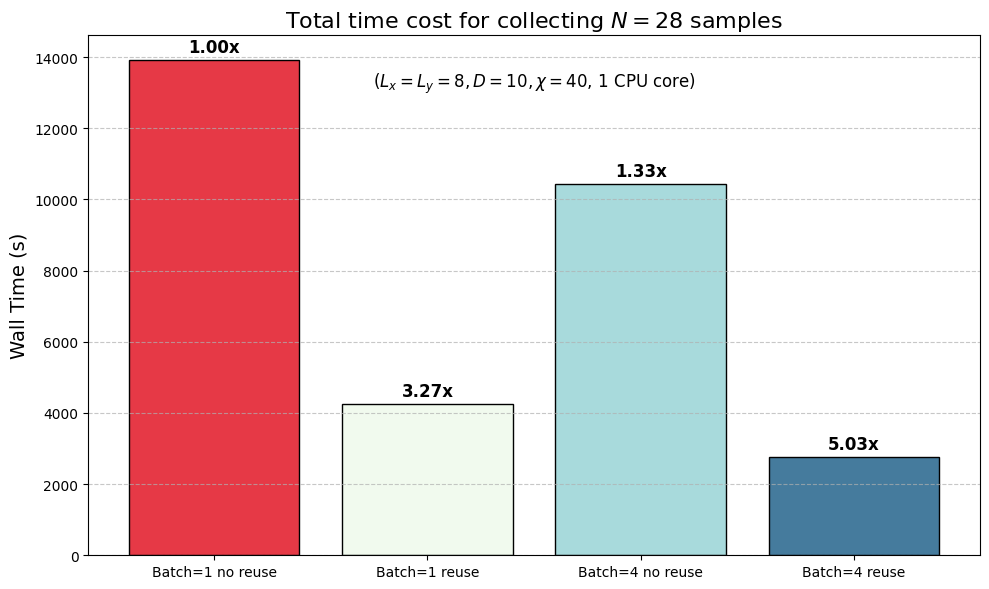

In [15]:
import matplotlib.pyplot as plt

# Data
B1_no_reuse = 497 * 28
B1_reuse = 152 * 28
B4_no_reuse = 1491 * 7
B4_reuse = 395 * 7

times = [B1_no_reuse, B1_reuse, B4_no_reuse, B4_reuse]
labels = ['Batch=1 no reuse', 'Batch=1 reuse', 'Batch=4 no reuse', 'Batch=4 reuse']
# Calculate speedup relative to the baseline
speedups = [B1_no_reuse / t for t in times]

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(labels, times, color=['#e63946', '#f1faee', '#a8dadc', '#457b9d'], edgecolor='black')

# Labeling speedup on top
# fmt='%.2f' handles the float formatting
# padding is the distance between bar top and text
ax.bar_label(bars, labels=[f'{s:.2f}x' for s in speedups], padding=3, fontsize=12, fontweight='bold')

ax.set_ylabel('Wall Time (s)', fontsize=14)
ax.set_title(r'Total time cost for collecting $N=28$ samples', fontsize=16)
ax.text(0.5, 0.9, '($L_x=L_y=8, D=10, \chi=40$, 1 CPU core)', fontsize=12, ha='center', transform=ax.transAxes)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('./debug/pure_fPEPS_timing.pdf', dpi=300)
plt.show()

In [ ]:
# performance degrade when multiple cores are used on one node
# probably due to memory bandwidth contention